### RaschPy global MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Description(page 135 - RaschPy/RaschPy_manual.pdf):
Creates an object of the class MFRM from a pandas multiindex dataframe of polytomously scored data of items, rated by multiple raters which share the same maximum score for analysis. Return and object of class MFRM. Analyses are run using methods defined on the MFRM object, with results stored as attributes of the MFRM object.

self.dataframe (pandas multiindex dataframe): Dataframe of valid responses.
self.invalid responses (pandas multiindex dataframe): Dataframe of invalid responses (persons with no responses to any items, i.e. all missing data).

Import the modules and set the working directory (here called `my_working_directory`)to where you have saved the `mfrm_global_scores.csv` file - you will also save your output files here.

# reading the filepaths and converting to MFRM fromat

In [35]:
all_filepaths = read_filepaths(DATA_DIR)

filepath_gold = all_filepaths['gold']
filepath_GPT5= all_filepaths['GPT5_mono']
filepath_gpt5mini_modu= all_filepaths['gpt_5-mini_modu']
filepath_gpt5mini_mono= all_filepaths['gpt_5-mini_mono']
filepath_claude_modu= all_filepaths['claude_modu']
filepath_claude_mono= all_filepaths['claude_mono']
filepath_gemini_modu= all_filepaths['gemini_modu']
filepath_gemini_mono= all_filepaths['gemini_mono']
filepath_deepseek_modu= all_filepaths['deepseek_modu']
filepath_deepseek_mono= all_filepaths['deepseek_mono']

pd_dataframes, all_files, concat_df = creating_mfrm_ready_data(filepath_gold, filepath_GPT5, 
                                                               filepath_claude_mono, filepath_claude_modu, 
                                                               filepath_gpt5mini_mono, filepath_gpt5mini_modu, 
                                                               filepath_gemini_mono, filepath_gemini_modu, 
                                                               filepath_deepseek_mono,filepath_deepseek_modu,
                                                               output_dir=OUTPUT_DIR) 


Combined dataset:
Total rows in concatenated filtered df: 2855
Unique comments: 250
Unique raters: 591

checking for missing values

[Problem] WARNING: Missing values detected:
respect          151
insult           151
humiliate        151
status           158
dehumanize       151
violence         151
genocide         151
attack_defend    151
dtype: int64


In [192]:
pd_dataframes['gold'].shape  #number of comment in the original gold dataset

(605, 17)

In [134]:
concat_df['annotator_id'].value_counts().head(10)

annotator_id
gpt-5_mono         250
claude_mono        250
claude_modu        250
gpt-5-mini_mono    250
gpt-5-mini_modu    250
gemini_mono        250
gemini_modu        250
deepseek_mono      250
deepseek_modu      250
6177                 4
Name: count, dtype: int64

In [12]:
# base_dir_2 = Path(output_dir)
all_filepaths = read_filepaths(base_dir=OUTPUT_DIR)

def calibrate(filepath, label):
    """Helper to load and calibrate MFRM model."""
    print(f"  Calibrating {label}...")
    data, _ = rp.loadup_mfrm_single(filepath)
    model   = rp.MFRM(data)
    model.calibrate_global()
    return model

gold_data            = str(all_filepaths['gold'])
GPT5_mono_data       = str(all_filepaths['GPT5_mono'])
gpt5mini_mono_data   = str(all_filepaths['gpt_5-mini_mono'])
gpt5mini_modu_data   = str(all_filepaths['gpt_5-mini_modu'])
claude_mono_data     = str(all_filepaths['claude_mono'])
claude_modu_data     = str(all_filepaths['claude_modu'])
gemini_mono_data     = str(all_filepaths['gemini_mono'])
gemini_modu_data     = str(all_filepaths['gemini_modu'])
deepseek_mono_data   = str(all_filepaths['deepseek_mono']) 
deepseek_modu_data   = str(all_filepaths['deepseek_modu']) 

# Combined files
llm_human_mod_mono   = str(all_filepaths['llm_human_mod_mono']) # question for team,
llm_only_mod_mono    = str(all_filepaths['llm_only_mod_mono'])
llm_only_mono        = str(all_filepaths['llm_only_mono'])
llm_only_modu        = str(all_filepaths['llm_only_modu'])
llm_mono_nogpt5      = str(all_filepaths['llm_mono_nogpt5'])

# =============================================================================
# CALIBRATE SEPARATE MODELS WITH MFRM
# =============================================================================
print("\nCalibrating separate models...")

# Individual annotator models
mfrm_humans        = calibrate(gold_data,           'Humans only')
mfrm_GPT5_mono     = calibrate(GPT5_mono_data,      'GPT5_mono')
mfrm_gpt5mini_mono = calibrate(gpt5mini_mono_data,  'GPT-5-mini mono')
mfrm_gpt5mini_modu = calibrate(gpt5mini_modu_data,  'GPT-5-mini modu')
mfrm_claude_mono   = calibrate(claude_mono_data,    'Claude mono')
mfrm_claude_modu   = calibrate(claude_modu_data,    'Claude modu')
mfrm_gemini_mono   = calibrate(gemini_mono_data,    'Gemini mono')
mfrm_gemini_modu   = calibrate(gemini_modu_data,    'Gemini modu')
mfrm_deepseek_mono = calibrate(deepseek_mono_data,  'DeepSeek mono')
mfrm_deepseek_modu = calibrate(deepseek_modu_data,  'DeepSeek modu')

# Combined models
mfrm_llms_only           = calibrate(llm_only_mod_mono,  'All LLMs mono+modu')
mfrm_llms_mono           = calibrate(llm_only_mono,      'All LLMs mono only')
mfrm_llms_mono_nogpt5    = calibrate(llm_mono_nogpt5,    'LLMs mono-no GPT5')
mfrm_llms_modu           = calibrate(llm_only_modu,      'All LLMs modu only')
mfrm_all                 = calibrate(llm_human_mod_mono, 'All raters combined')
# mfrm_all_unfil           = calibrate(llm_)

print("\n✓ All models calibrated")
# =============================================================================
# EXTRACT ITEM DIFFICULTIES and determing strictest and most lenient LLMs
# =============================================================================

comparison = pd.DataFrame({
    'humans'           : mfrm_humans.diffs,
    'GPT5_mono'        : mfrm_GPT5_mono.diffs,
    'gpt5mini_mono'    : mfrm_gpt5mini_mono.diffs,
    'gpt5mini_modu'    : mfrm_gpt5mini_modu.diffs,
    'claude_mono'      : mfrm_claude_mono.diffs,
    'claude_modu'      : mfrm_claude_modu.diffs,
    'gemini_mono'      : mfrm_gemini_mono.diffs,
    'gemini_modu'      : mfrm_gemini_modu.diffs,
    'deepseek_mono'    : mfrm_deepseek_mono.diffs,
    'deepseek_modu'    : mfrm_deepseek_modu.diffs,
    'llm_only_mono'    : mfrm_llms_mono.diffs,
    'llm_mono_nogpt5'  : mfrm_llms_mono_nogpt5.diffs,
    'llm_only_modu'    : mfrm_llms_modu.diffs,
    'llm_only_mod_mono': mfrm_llms_only.diffs,
    'llm_human_all'    : mfrm_all.diffs,
    # 'llm_huma_all_unfil' : mfrm_all_unfil.diffs,
})

# LLM_COLS =LLM_NAMES[:-2]                    

# Human vs LLM mono difference
comparison['Hu_vs_LLM_mono'] = comparison['humans'] - comparison['llm_only_mono']
comparison['interpretation_hu_llm(mono)'] = comparison['Hu_vs_LLM_mono'].apply(
    lambda x: 'LLM Stricter (Finds Harder)' if x < 0 else 'LLM Lenient (Finds Easier)'
)

# Human vs LLM mono excluding GPT5 difference
comparison['Hu_vs_LLM_mono_nogpt5'] = comparison['humans'] - comparison['llm_mono_nogpt5']
comparison['interpretation_hu_llm(mono_nogppt5)'] = comparison['Hu_vs_LLM_mono_nogpt5'].apply(
    lambda x: 'LLM Stricter (Finds Harder)' if x < 0 else 'LLM Lenient (Finds Easier)'
)

# Human vs LLM modu difference
comparison['Hu_vs_LLM_modu'] = comparison['humans'] - comparison['llm_only_modu']
comparison['interpretation_hu_llm(modu)'] = comparison['Hu_vs_LLM_modu'].apply(
    lambda x: 'LLM Stricter (Finds Harder)' if x < 0 else 'LLM Lenient (Finds Easier)'
)

LLM_COLS = [col for col in comparison.columns if col in LLM_NAMES] #llm names only contains original llms names
# Determine strictest and most lenient LLMs (mono and modu)
comparison['Strictest_LLM']    = comparison.apply(
    lambda row: interpret_strictest_llm(row, llm_cols=LLM_COLS), axis=1
)
comparison['Most_Lenient_LLM'] = comparison.apply(
    lambda row: interpret_most_lenient_llm(row, llm_cols=LLM_COLS), axis=1
)

# Rankings
for col in ['humans', 'llm_only_mono', 'llm_only_mono','llm_only_mod_mono', ]:
    comparison[f'{col}_rank'] = comparison[col].rank()

# =============================================================================
# ITEM DIFFICULTY COMPARISONS
# =============================================================================
print("\n" + "="*80)
print("ITEM DIFFICULTY ANALYSIS")
print("="*80)


all_llms_comparison = {
    'GPT5_mono'        : mfrm_GPT5_mono.diffs,
    'gpt5mini_mono'    : mfrm_gpt5mini_mono.diffs,
    'gpt5mini_modu'    : mfrm_gpt5mini_modu.diffs,
    'claude_mono'      : mfrm_claude_mono.diffs,
    'claude_modu'      : mfrm_claude_modu.diffs,
    'gemini_mono'      : mfrm_gemini_mono.diffs,
    'gemini_modu'      : mfrm_gemini_modu.diffs,
    'deepseek_mono'    : mfrm_deepseek_mono.diffs,
    'deepseek_modu'    : mfrm_deepseek_modu.diffs }

all_merged_llms_comparisons={
    'llm_only_mono'    : mfrm_llms_mono.diffs,
    'llm_mono_nogpt5'  : mfrm_llms_mono_nogpt5.diffs,
    'llm_only_modu'    : mfrm_llms_modu.diffs,
    'llm_only_mod_mono': mfrm_llms_only.diffs,
    'llm_human_all'    : mfrm_all.diffs,
}

print('***Human vs individual LLM correlations***')
for name, mfrm_diffs in all_llms_comparison.items():
    corr_hu_llm = mfrm_humans.diffs.corr(mfrm_diffs)
    print(f"Correlation Human vs {name}: r={corr_hu_llm:.3f}")

print('\n***Human vs combined LLM correlations****')   
for name_merged, mfrm_merged_diffs in all_merged_llms_comparisons.items():
    corr_hu_llm_merged = mfrm_humans.diffs.corr(mfrm_merged_diffs)
    print(f"Correlation Human vs {name_merged}: r={corr_hu_llm_merged:.3f}")


print('\n***Monolithic vs Modular Corrlations****')   
corr_gpt5mini_mono_modu = mfrm_gpt5mini_mono.diffs.corr(mfrm_gpt5mini_modu.diffs)
print(f"Correlation GPT-5-mini mono vs modu: r={corr_gpt5mini_mono_modu:.3f}")

corr_claude_mono_modu = mfrm_claude_mono.diffs.corr(mfrm_claude_modu.diffs)
print(f"Correlation Claude mono vs modu: r={corr_claude_mono_modu:.3f}")

corr_gemini_mono_modu = mfrm_gemini_mono.diffs.corr(mfrm_gemini_modu.diffs)
print(f"Correlation Gemini mono vs modu: r={corr_gemini_mono_modu:.3f}")

corr_deepseek_mono_modu = mfrm_deepseek_mono.diffs.corr(mfrm_deepseek_modu.diffs)
print(f"Correlation DeepSeek mono vs modu: r={corr_deepseek_mono_modu:.3f}")

print("\n\n" + "="*300)
print("FULL ITEM DIFFICULTY COMPARISON TABLE")
print("="*300)
print(comparison.round(3).to_string())


Calibrating separate models...
  Calibrating Humans only...
  Calibrating GPT5_mono...
  Calibrating GPT-5-mini mono...
  Calibrating GPT-5-mini modu...
  Calibrating Claude mono...
  Calibrating Claude modu...
  Calibrating Gemini mono...
  Calibrating Gemini modu...
  Calibrating DeepSeek mono...
  Calibrating DeepSeek modu...
  Calibrating All LLMs mono+modu...
  Calibrating All LLMs mono only...
  Calibrating LLMs mono-no GPT5...
  Calibrating All LLMs modu only...
  Calibrating All raters combined...

✓ All models calibrated

ITEM DIFFICULTY ANALYSIS
***Human vs individual LLM correlations***
Correlation Human vs GPT5_mono: r=0.929
Correlation Human vs gpt5mini_mono: r=0.929
Correlation Human vs gpt5mini_modu: r=0.931
Correlation Human vs claude_mono: r=0.885
Correlation Human vs claude_modu: r=0.834
Correlation Human vs gemini_mono: r=0.910
Correlation Human vs gemini_modu: r=0.926
Correlation Human vs deepseek_mono: r=0.948
Correlation Human vs deepseek_modu: r=0.883

***Human 

# rater severity(alpha[j]) stats and plot/

In [13]:
mfrm_all.rater_stats_df_global() 
severity_df = mfrm_all.rater_stats_global
severity_df, severity_for_plotting = get_severity(severity_df)
severity_df.tail(10)

Index(['Rater', 'Estimate', 'SE', 'Count', 'Infit MS', 'Outfit MS'], dtype='str')


,annotator,severity,SE,Count,Infit MS,Outfit MS,rater_type
577,9982,1.777,0.200,10,2.438,2.501,Human
578,claude_modu,-0.855,0.030,2261,1.592,1.310,claude_modu
579,claude_mono,-0.517,0.027,2236,1.268,1.256,claude_mono
580,deepseek-v4-flash_modu,-1.104,0.032,2356,2.163,1.723,deepseek_modu
581,deepseek-v4-flash_mono,-0.361,0.028,2388,1.655,1.936,deepseek_mono
582,gemini_modu,-0.665,0.030,2484,1.807,1.520,gemini_modu
583,gemini_mono,-0.424,0.026,2468,1.699,1.504,gemini_mono
584,gpt-5-mini_modu,-1.666,0.035,2364,2.513,1.973,gpt-5-mini_modu
585,gpt-5-mini_mono,-0.879,0.029,2380,1.944,1.611,gpt-5-mini_mono
586,gpt-5_mono,0.324,0.027,2348,1.610,1.794,GPT5_mono


# to compute the severity uniquely without fitting sttistics

In [25]:
severity_series = (
    pd.Series(mfrm_all.severities_global, name='severity')
    .reset_index()
    .rename(columns={'index': 'Rater'})
)

severity_df, severity_for_plotting_2 = get_severity(severity_series)
print(severity_df.tail(10))

Index(['index', 'Rater', 'severity'], dtype='str')
     index        annotator  severity       rater_type
581    581             9982  1.780782            Human
582    582      claude_modu -0.851985      claude_modu
583    583      claude_mono -0.514043      claude_mono
584    584    deepseek_modu -1.101184    deepseek_modu
585    585    deepseek_mono -0.357789    deepseek_mono
586    586      gemini_modu -0.661446      gemini_modu
587    587      gemini_mono -0.420453      gemini_mono
588    588  gpt-5-mini_modu -1.663484  gpt-5-mini_modu
589    589  gpt-5-mini_mono -0.875668  gpt-5-mini_mono
590    590       gpt-5_mono  0.327132        GPT5_mono


## Plotting the raters severity 

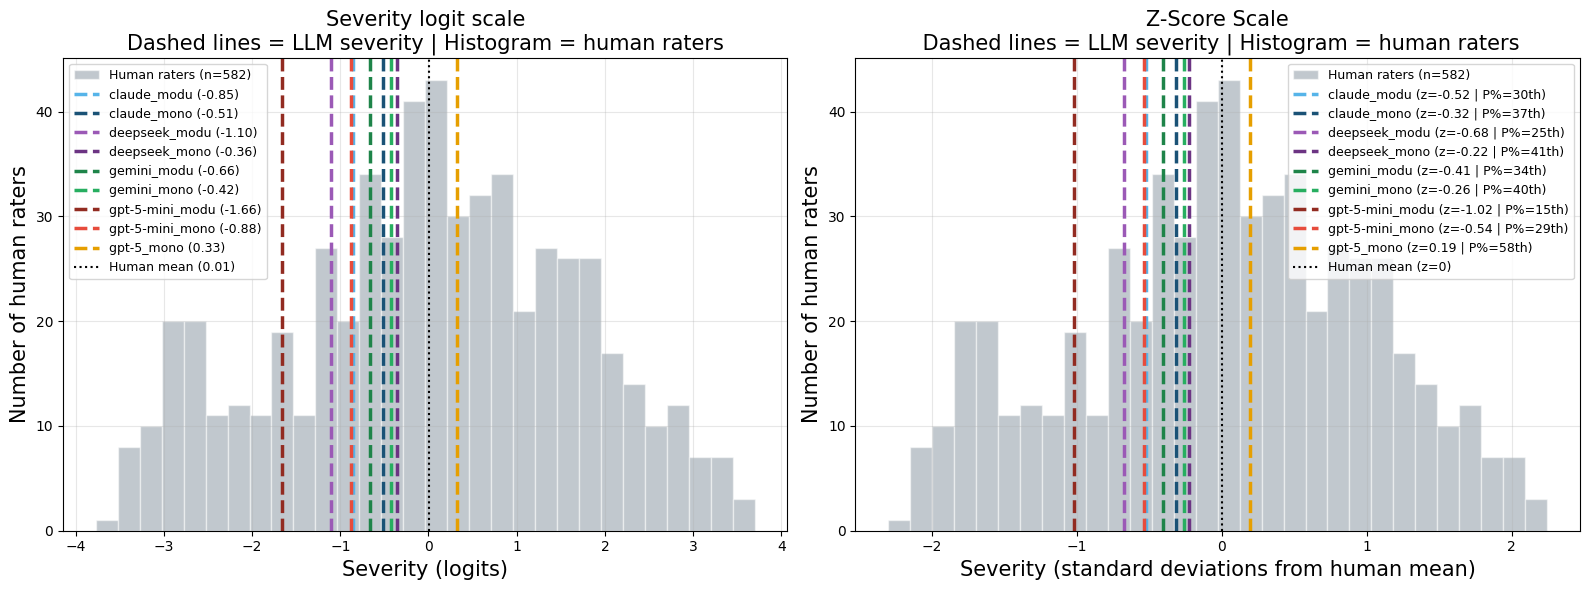

In [34]:
# Run plotting functions
from config import COLORS
# plot_severity_strip(severity_for_plotting, colors=COLORS)
plot_severity_with_context_zscore(severity_for_plotting_2, colors=COLORS)

# Person's ability (theta[n])

The "Persons" in this table represent the specific comments in the dataset. Interpreting other columns:

**Estimate ($\theta_n$)**
This is the central output you are looking for—the **final continuous hate speech score** for each comment. It is calculated on a logit scale.
- Comment with highly positive estimate -->  it was rated as the most severe/hateful comment.
- Comment with highly negative estimate -->  it was rated as the least severe/hateful comment.

## Extract and comparing person ability estimates (theta) 

### Ground_Truth:  what hate score do the individual llm and humans produce

In [15]:

# =============================================================================
# EXTRACT ALL THETAS
# =============================================================================
# def extract_theta(mfrm, label=""):
#     mfrm.person_stats_df_global()
#     theta = mfrm.person_stats_global.get('Estimate')
#     if theta is None or theta.empty:
#         raise ValueError(f"No theta estimates found for: {label}")
#     theta.index.name = 'comment_id'
#     return theta
# ── Extract all thetas ────────────────────────────────────────────────────────
thetas = {
    'human'         : extract_theta(mfrm_humans,        'human'),
    'GPT5_mono'     : extract_theta(mfrm_GPT5_mono,     'GPT5_mono'),
    'gpt-5-mini_mono' : extract_theta(mfrm_gpt5mini_mono, 'gpt-5-mini_mono'),
    'gpt-5-mini_modu' : extract_theta(mfrm_gpt5mini_modu, 'gpt-5-mini_modu'),
    'claude_mono'   : extract_theta(mfrm_claude_mono,   'claude_mono'),
    'claude_modu'   : extract_theta(mfrm_claude_modu,   'claude_modu'),
    'gemini_mono'   : extract_theta(mfrm_gemini_mono,   'gemini_mono'),
    'gemini_modu'   : extract_theta(mfrm_gemini_modu,   'gemini_modu'),
    'deepseek_mono' : extract_theta(mfrm_deepseek_mono, 'deepseek_mono'),
    'deepseek_modu' : extract_theta(mfrm_deepseek_modu, 'deepseek_modu'),
    'joint'         : extract_theta(mfrm_all,           'joint'),
}

all_theta_df = pd.DataFrame(thetas)
print(f"Shape after alignment: {all_theta_df.shape}")
print(f"Comments in all models: {len(all_theta_df)}")
# print(f"\nFirst 5 rows:")
# print(all_theta_df.head().round(3))


# =============================================================================
# PART 1 — Individual models vs human
# =============================================================================
print("\n" + "="*75)
print("PART 1: INDIVIDUAL MODELS — Each LLM calibrated separately")
print("="*75)

print(f"\n{'Pair':<35} {'r':>6} {'p':>12} {'MAE':>7} {'Bias':>8}")
print("-"*75)

cols = [c for c in all_theta_df.columns if c != 'joint']

for name_a, name_b in combinations(cols, 2):
    theta_a = all_theta_df[name_a]
    theta_b = all_theta_df[name_b]

    r, p  = stats.pearsonr(theta_a, theta_b)
    mae   = (theta_a - theta_b).abs().mean()
    bias  = (theta_b - theta_a).mean()
    pair  = f"{name_a} vs {name_b}"
    print(f"{pair:<35} {r:>6.3f} {p:>12.6f} {mae:>7.3f} {bias:>8.3f}")

# =============================================================================
# PART 2 — Each LLM vs human
# =============================================================================
print("\n" + "="*75)
print("PART 2: JOINT MODEL — All raters calibrated together")
print("Does joint calibration improve agreement with human scores?")
print("="*75)

print(f"\n{'LLM':<16} {'r':>6} {'p':>10} {'MAE':>7} {'Bias':>8}")
print("-"*55)

llm_cols = [c for c in all_theta_df.columns if c not in ('human', 'joint')]

for name in llm_cols:
    theta_a = all_theta_df['human']
    theta_b = all_theta_df[name]

    r, p  = stats.pearsonr(theta_a, theta_b)
    mae   = (theta_a - theta_b).abs().mean()
    bias  = (theta_b - theta_a).mean()
    pair  = f"{name} vs {name_b}"
    print(f"{name:<16} {r:>6.3f} {p:>10.6f} {mae:>7.3f} {bias:>8.3f}")
    # {name:<16} {r:>6.3f} {p:>10.6f} {mae:>7.3f} {bias:>8.3f}")

# =============================================================================
# PART 3 — Joint vs human
# =============================================================================
print(f"\n--- Joint model vs human ---")
a = all_theta_df['human']
b = all_theta_df['joint']

r, p   = stats.pearsonr(a, b)
mae    = (a - b).abs().mean()
bias   = (b - a).mean()
print(f"r={r:.3f}  p={p:.6f}  MAE={mae:.3f}  Bias={bias:.3f}")

# =============================================================================
# PART 4 — Summary statistics
# =============================================================================
print(f"\nSummary statistics:")
print(all_theta_df.describe().round(3).to_string())

Shape after alignment: (250, 11)
Comments in all models: 250

PART 1: INDIVIDUAL MODELS — Each LLM calibrated separately

Pair                                     r            p     MAE     Bias
---------------------------------------------------------------------------
human vs GPT5_mono                   0.753     0.000000   1.140   -0.140
human vs gpt-5-mini_mono             0.710     0.000000   1.242    0.333
human vs gpt-5-mini_modu             0.697     0.000000   1.291    0.282
human vs claude_mono                 0.687     0.000000   1.129    0.551
human vs claude_modu                 0.702     0.000000   1.228    0.743
human vs gemini_mono                 0.748     0.000000   1.377    0.403
human vs gemini_modu                 0.759     0.000000   1.207    0.447
human vs deepseek_mono               0.718     0.000000   1.470    0.373
human vs deepseek_modu               0.736     0.000000   1.014    0.525
GPT5_mono vs gpt-5-mini_mono         0.840     0.000000   0.920    0.473

In [172]:
all_theta_df.head()

,human,GPT5_mono,gpt5mini_mono,gpt5mini_modu,claude_mono,claude_modu,gemini_mono,gemini_modu,deepseek_mono,deepseek_modu,joint
comment_id,,,,,,,,,,,
170,0.773,0.086,2.124,1.070,0.224,-0.118,2.102,2.225,1.914,1.648,0.950
364,1.712,1.410,1.602,1.510,1.432,1.668,1.426,1.174,1.914,0.946,0.765
401,0.964,0.086,0.135,-0.122,0.224,-0.118,1.417,1.479,0.505,0.413,0.569
423,1.311,1.194,1.602,2.008,0.750,0.973,1.426,1.361,2.161,1.323,0.689
545,2.706,3.337,3.362,5.069,4.219,4.609,5.269,4.638,5.397,4.221,3.424


## Analysis 2: Plots severity distribution for all models with bias, slope ...

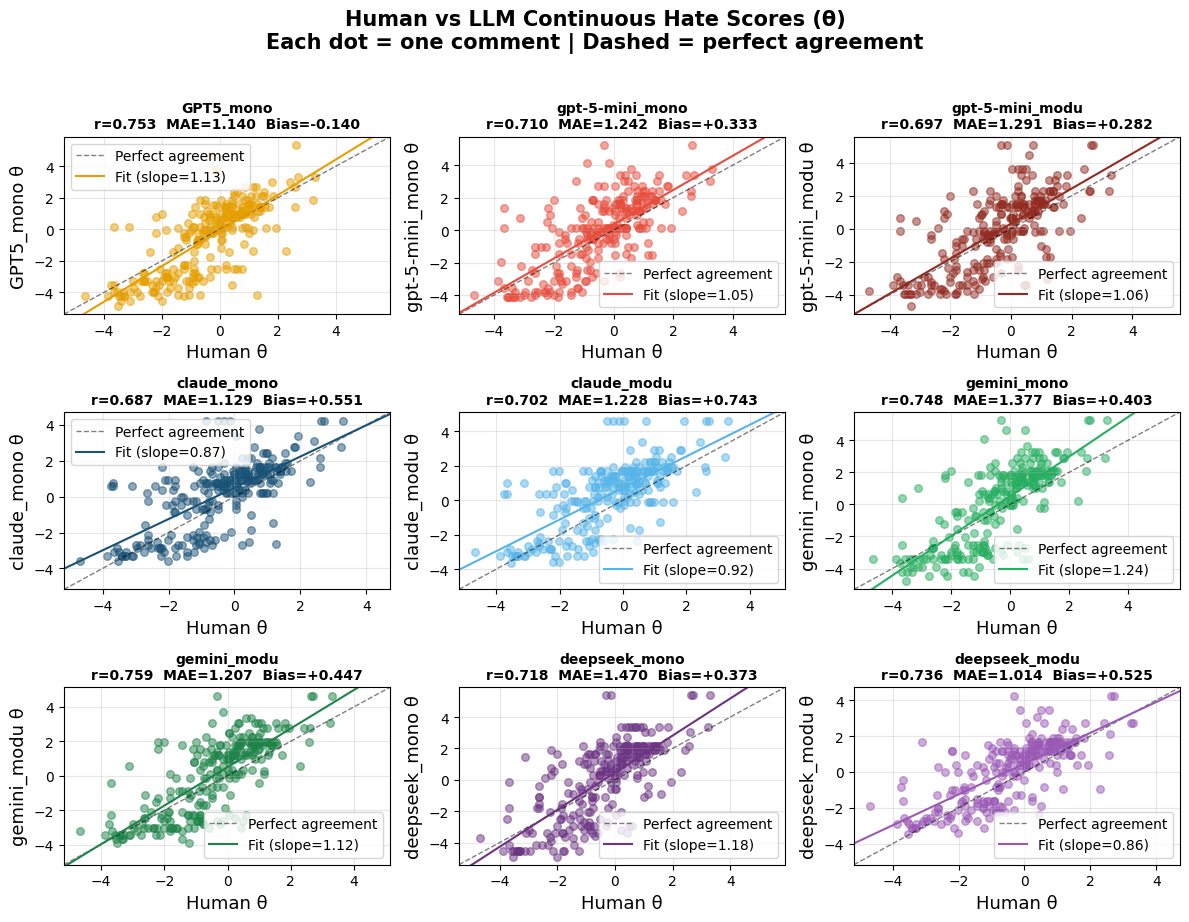

In [23]:
plot_human_vs_llm_scatter_theta(all_theta_df)

## Analysis 3 — Bias Direction by Comment Severity Quartile
This answers: do LLMs underestimate only mild hate or also extreme hate?


Quartile Bias Analysis
Positive bias = LLM rates HIGHER than human
Negative bias = LLM rates LOWER than human

                GPT5_mono  gpt-5-mini_mono  gpt-5-mini_modu  claude_mono  claude_modu  gemini_mono  gemini_modu  deepseek_mono  deepseek_modu
human_quartile                                                                                                                               
Q1\n(Mild)         -0.595            0.047            0.018        0.738        0.835       -0.140        0.192         -0.123          0.765
Q2\n(Moderate)     -0.189            0.419            0.187        0.624        0.775        0.158        0.219          0.265          0.402
Q3\n(Serious)       0.320            0.558            0.654        0.589        0.877        0.815        0.691          0.764          0.717
Q4\n(Extreme)      -0.090            0.314            0.275        0.256        0.489        0.781        0.685          0.592          0.218


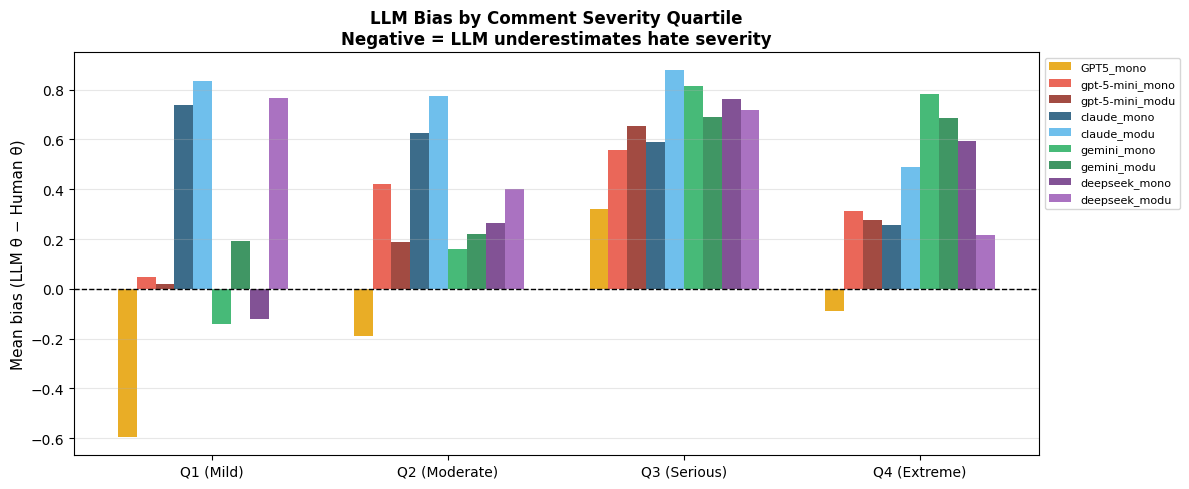

In [183]:
def analyze_bias_by_severity_quartile(all_theta_df):
    """
    Split comments into quartiles by human severity.
    Compute LLM bias within each quartile.
    """
    df = all_theta_df.copy()
    df['human_quartile'] = pd.qcut(
        df['human'], q=4,
        labels=['Q1\n(Mild)', 'Q2\n(Moderate)', 
                'Q3\n(Serious)', 'Q4\n(Extreme)']
    )

    llm_cols = [c for c in df.columns 
                if c not in ('human', 'joint', 'human_quartile')]

    print(f"\n{'Quartile Bias Analysis':}")
    print(f"Positive bias = LLM rates HIGHER than human")
    print(f"Negative bias = LLM rates LOWER than human\n")

    bias_by_quartile = {}
    for name in llm_cols:
        df[f'bias_{name}'] = df[name] - df['human']
        bias_by_quartile[name] = df.groupby('human_quartile')[
            f'bias_{name}'
        ].mean()

    bias_df = pd.DataFrame(bias_by_quartile)
    print(bias_df.round(3).to_string())

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(4)
    width = 0.08
    
    for i, name in enumerate(llm_cols):
        color = COLORS.get(name, '#888')
        ax.bar(x + i * width, bias_df[name],
               width=width, label=name, color=color, alpha=0.85)

    ax.axhline(0, color='black', lw=1, linestyle='--')
    ax.set_xticks(x + width * len(llm_cols) / 2)
    ax.set_xticklabels(['Q1 (Mild)', 'Q2 (Moderate)', 
                        'Q3 (Serious)', 'Q4 (Extreme)'])
    ax.set_ylabel('Mean bias (LLM θ − Human θ)', fontsize=11)
    ax.set_title(
        'LLM Bias by Comment Severity Quartile\n'
        'Negative = LLM underestimates hate severity',
        fontsize=12, fontweight='bold'
    )
    ax.legend(fontsize=8, bbox_to_anchor=(1, 1))
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    return bias_df

bias_by_quartile = analyze_bias_by_severity_quartile(all_theta_df)

# Stop here for now

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Config imported successfully!


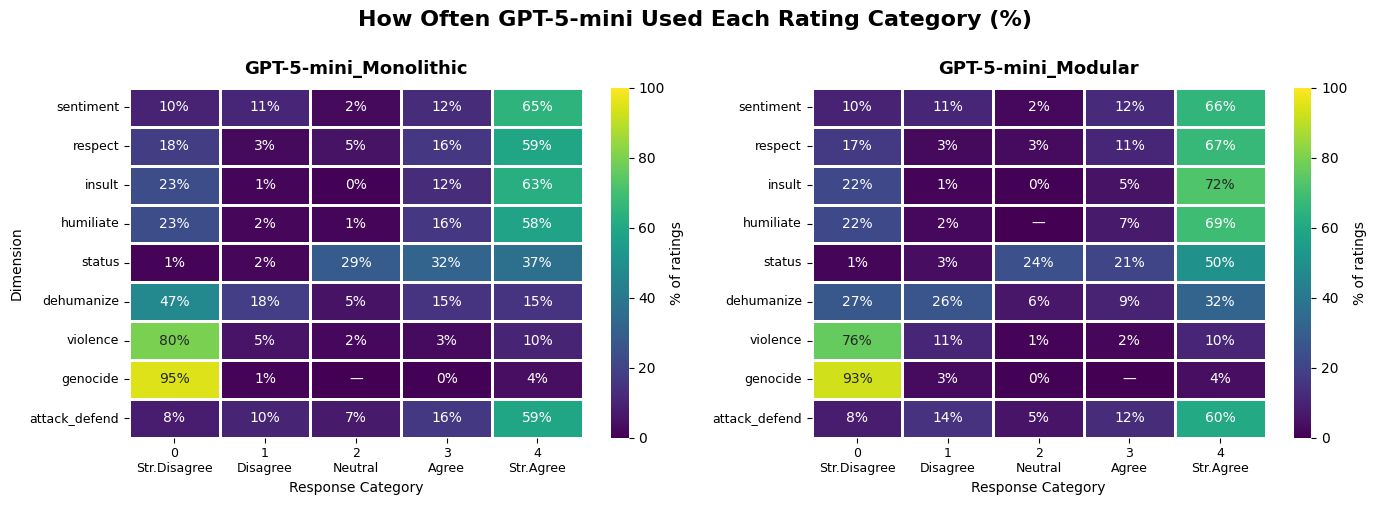

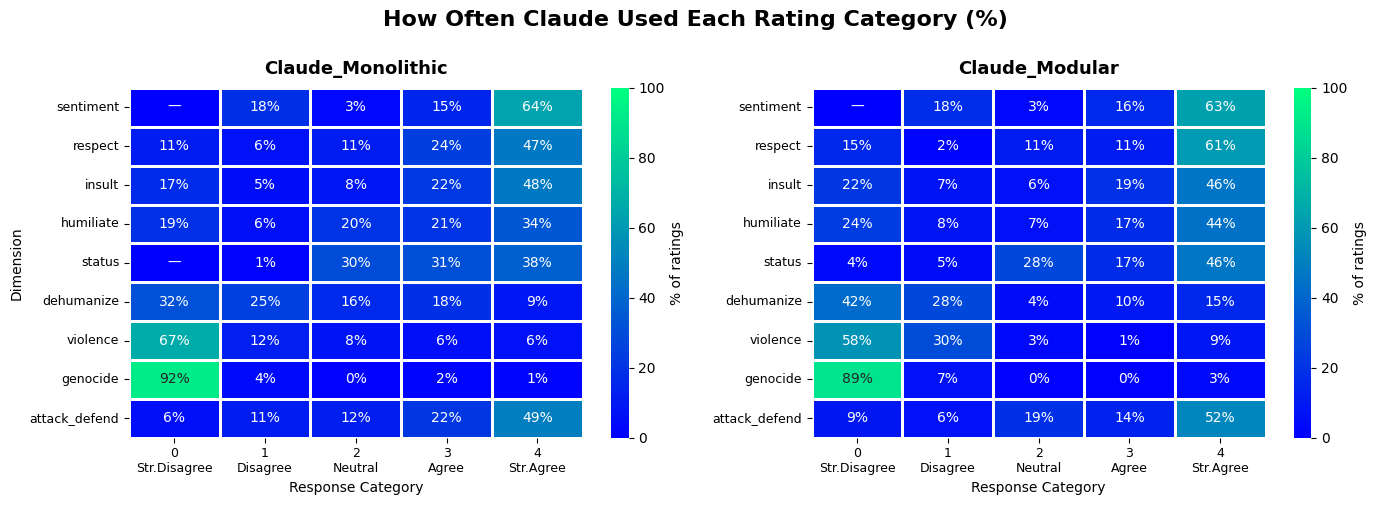

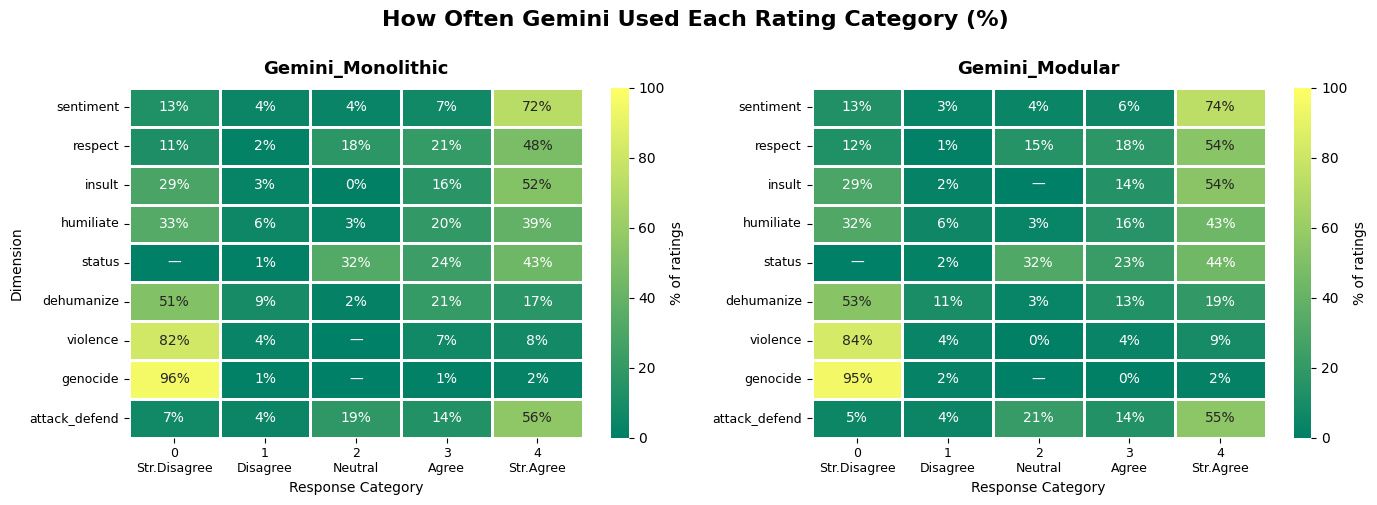

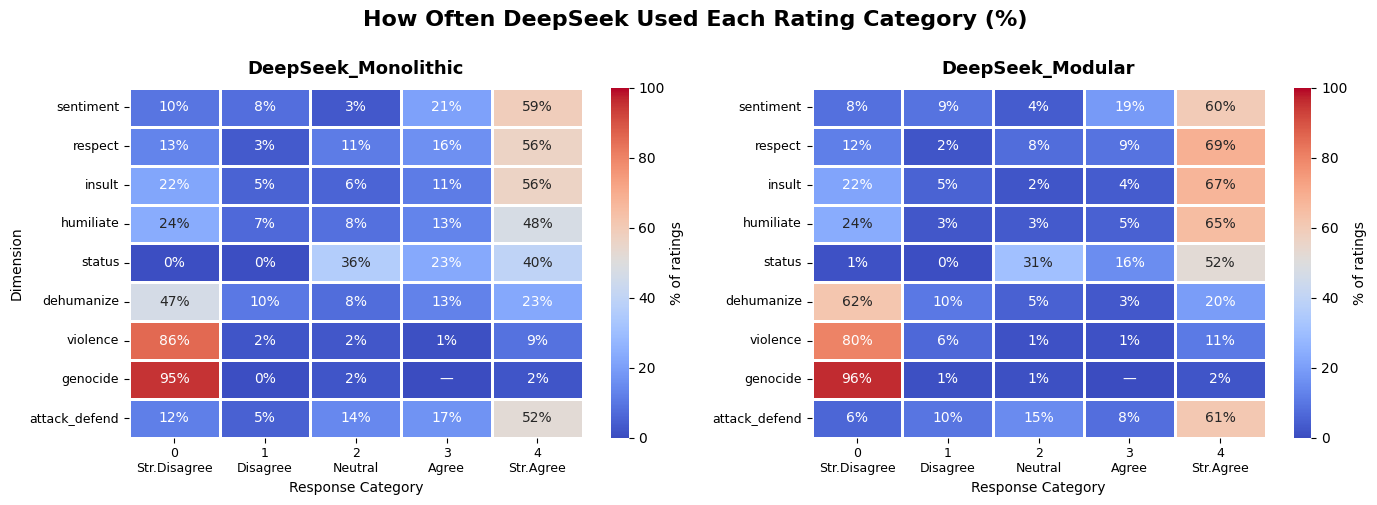

In [ ]:
%load_ext autoreload
%autoreload 2

###########################################################################################
# Assessing the overall distribution of GPT's (Mono and Modu) ratings across all dimensions
############################################################################################
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

import seaborn as sns
from datetime import datetime
from pathlib import Path
import os, math
import RaschPy as rp
import warnings
import sys

from scipy import stats
from itertools import combinations


warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Add the project root to the system path for imports scinec config not in the same directory as this script
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

# analysis_project_root = os.path.abspath(os.path.join(os.path.dirname(__file__), '..'))
# sys.path.insert(0, project_root)

import config
print(f"Config imported successfully!")

from Analysis.mfrm_analysis import (read_filepaths,
                          data_differentiate_raters_3, 
                          creating_mfrm_ready_data, 
                          interpret_strictest_llm, 
                          interpret_most_lenient_llm,  
                          get_severity, 
                          plot_severity_strip, 
                          plot_severity_with_context_zscore, 
                          plot_human_vs_llm_scatter_theta,
                          extract_theta)
from config import (COLORS, 
                   DIMENSIONS, 
                   ORDINAL_DIMS, 
                   OUTPUT_DIR, 
                   LLM_NAMES, 
                   ANNOTATOR_ID_MAP, 
                   DATA_DIR, 
                   DATA_DIR_RAW, 
                   DATA_DIR_MFRM)


gpt5mini_mono   = pd.read_csv('../AIES_2026/final_AIES_2026/data/patched_data/gpt-5-mini_mono_patched_20260429_175401.csv')
gpt5mini_modu   = pd.read_csv('../AIES_2026/final_AIES_2026/data/patched_data/gpt-5-mini_modu_patched_20260430_001603.csv')
claude_mono     = pd.read_csv('../AIES_2026/final_AIES_2026/data/patched_data/claude-haiku-4.5_mono_patched_20260428_004314.csv')
claude_modu     = pd.read_csv('../AIES_2026/final_AIES_2026/data/patched_data/claude-haiku-4.5_modu_patched_20260428_004314.csv')
gemini_mono     = pd.read_csv('../AIES_2026/final_AIES_2026/data/patched_data/gemini-2.5-flash_mono_patched_20260429_043637.csv')
gemini_modu     = pd.read_csv('../AIES_2026/final_AIES_2026/data/patched_data/gemini-2.5-flash_modu_patched_20260503_063944.csv')
deepseek_mono   = pd.read_csv('../AIES_2026/final_AIES_2026/data/patched_data/deepseek-v4-flash_mono_patched_20260502_021917.csv')
deepseek_modu   = pd.read_csv('../AIES_2026/final_AIES_2026/data/patched_data/deepseek-v4-flash_modu_patched_20260502_021917.csv')

all_models_dict = {
    'GPT-5-mini': (gpt5mini_mono, gpt5mini_modu, 'viridis'),
    'Claude': (claude_mono, claude_modu, 'winter'),
    'Gemini': (gemini_mono, gemini_modu, 'summer'),
    'DeepSeek': (deepseek_mono, deepseek_modu, 'coolwarm')
}
def plot_category_frequency_table(models_dict, ORDINAL_DIMS=ORDINAL_DIMS):

    ALL_CATS = [0, 1, 2, 3, 4]
    
    def get_pct_matrix(df):
        matrix = {}
        for item in ORDINAL_DIMS:
            col = df[item].dropna()
            total = len(col)
            matrix[item] = {
                cat: round((col == cat).sum() / total * 100, 1) if total > 0 else np.nan
                for cat in ALL_CATS
            }
        return pd.DataFrame(matrix).T
    for model_name, model_prompt_type in models_dict.items():
        mono_mat = get_pct_matrix(list(model_prompt_type)[0])
        modu_mat = get_pct_matrix(list(model_prompt_type)[1])

        cat_labels = ['0\nStr.Disagree', '1\nDisagree', '2\nNeutral', '3\nAgree', '4\nStr.Agree']

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))



        for ax, mat, title in zip(
            axes,
            [mono_mat, modu_mat],
            [f'{model_name}_Monolithic', f'{model_name}_Modular']
        ):
            annot = mat.map(lambda x: '—' if pd.isna(x) or x == 0 else f'{x:.0f}%')
            masked = mat.copy()
            masked[masked == 0] = np.nan 
            sns.heatmap(
                mat,
                ax=ax,
                annot=annot,
                fmt='',
                cmap=list(model_prompt_type)[2],
                vmin=0,
                vmax=100,
                linewidths=0.8,
                linecolor='white',
                cbar_kws={'label': '% of ratings'},
                annot_kws={'size': 10},
                # mask        = masked.isna()
            )

            ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
            ax.set_xlabel('Response Category', fontsize=10)
            ax.set_xticklabels(cat_labels, fontsize=9, rotation=0)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

        axes[0].set_ylabel('Dimension', fontsize=10)

        plt.suptitle(
            f'How Often {model_name} Used Each Rating Category (%)',
            fontsize=16,
            fontweight='bold',
            y=1.00
        )

        plt.tight_layout()
        plt.show()

plot_category_frequency_table(all_models_dict)